Importamos modulos necesarios

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time

 Exploración de datos del dataset (dataset exploration)

 ¿cual es la finalidad de la exploracion de los datos?
 - entender los datos
 - verificar la calidad de los datos
 - identificar patrones en los datos
 - determinar la relación entre las variables
 - determinar la importancia de las variables
 - determinar la distribución de las variables

In [2]:
# cargamos el archivo csv usando la librería pandas
dataset = pd.read_csv('../data/data.csv')
# revisamos el dataset
print('dataset head:\n', dataset.head(), '\n')
# ¿que observamos con el metodo head?
# - que el dataset tiene 33 columnas
# - que la primer columna es un id
# - que la segunda columna es el diagnostico (M o B)
# - que las siguientes columnas son valores numéricos
# - que la última columna es NaN

dataset head:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_wo

separamos los datos (data) de los valores objetivos (etiquetas, targets)

In [3]:
# obtenemos solamente la columna diagnostico (diagnosis) que es la que queremos predecir
targets = dataset['diagnosis'] # M o B
# target = dataset.diagnosis # asi tambien funciona
# revisamos los targets
print('targets:\n', targets.head(20), '\n')
print('targets shape:\n', targets.shape, '\n')
# ¿que observamos con el metodo shape?
# - que hay 569 filas
# - que hay 1 columna
# eliminamos la columna diagnosis del dataset, junto con otras que no necesitamos
data = dataset.drop(['id', 'diagnosis', 'Unnamed: 32'], axis=1)
# ¿de donde sacamos que las columnas que queremos eliminar se llaman asi?
# - del metodo head
# ¿porque eliminamos la columna diagnosis?
# - porque es la columna que queremos predecir
# ¿porque eliminamos la columna id?
# - porque no aporta información relevante
# ¿porque eliminamos la columna Unnamed: 32?
# - porque es NaN
# revisamos los datos
print('data:\n', data.head(20), '\n')
# ¿que observamos con el metodo head?
# - que hay 569 filas
# - que hay 30 columnas (antes habia 33 pero eliminamos 3)
# revisamos la forma de los datos
print('data shape:\n', data.shape, '\n')

targets:
 0     M
1     M
2     M
3     M
4     M
5     M
6     M
7     M
8     M
9     M
10    M
11    M
12    M
13    M
14    M
15    M
16    M
17    M
18    M
19    B
Name: diagnosis, dtype: object 

targets shape:
 (569,) 

data:
     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0         17.99         10.38          122.80     1001.0          0.11840   
1         20.57         17.77          132.90     1326.0          0.08474   
2         19.69         21.25          130.00     1203.0          0.10960   
3         11.42         20.38           77.58      386.1          0.14250   
4         20.29         14.34          135.10     1297.0          0.10030   
5         12.45         15.70           82.57      477.1          0.12780   
6         18.25         19.98          119.60     1040.0          0.09463   
7         13.71         20.83           90.20      577.9          0.11890   
8         13.00         21.82           87.50      519.8          0.1273

 verificando si el dataset esta balanceado
 ¿para que queremos saber si el dataset esta balanceado?
 - para saber si hay la (mas o menos) misma cantidad de muestras para cada clase
 - para saber si hay una clase que tiene mas muestras que otra
 - para saber si hay una clase que tiene menos muestras que otra

Numero de tumores benignos:  357
Numero de tumores malignos:  212


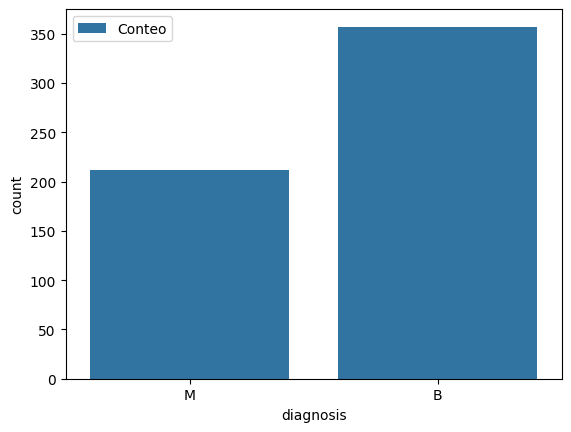

In [4]:
# contamos cuantos valores de cada tipo hay en la columna diagnosis
ax = sns.countplot(x=targets, label='Conteo')
B, M = targets.value_counts()
print('Numero de tumores benignos: ', B)
print('Numero de tumores malignos: ', M)
plt.show()

 verificamos la correlación entre las variables
 ¿que significa la correlacion entre las variables? ¿porque es importante?
 - la correlación entre las variables indica si las variables están relacionadas entre sí
 - es importante porque nos permite saber si una variable afecta a otra

In [5]:
#Setting style for the Seaborn graph
sns.set(style="whitegrid", palette="muted")
#Getting targets
data_dia = targets
#data normalization for plotting
data_n_2 = (data - data.mean()) / (data.std())


c:\Users\jrizz\Documentos\Programación\proyectos\AI\Supervised Machine Learning\Breast Cancer Detection\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 40.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\jrizz\Documentos\Programación\proyectos\AI\Supervised Machine Learning\Breast Cancer Detection\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 40.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\jrizz\Documentos\Programación\proyectos\AI\Supervised Machine Learning\Breast Cancer Detection\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 45.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\jrizz\Documentos\Programación\proyectos\AI\Supervised Machine Le

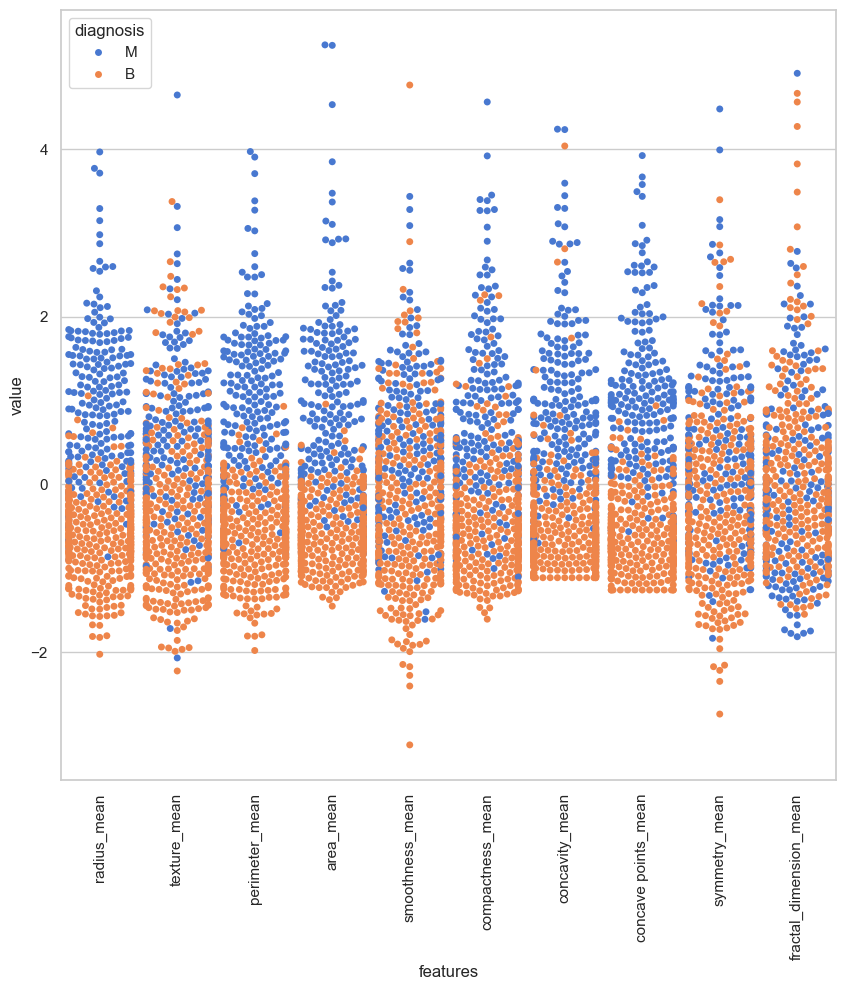

In [6]:
#Getting only first 10 features
data_vis = pd.concat([targets,data_n_2.iloc[:,0:10]],axis=1)
# ¿que hace el metodo concat?
# - concatena dos dataframes, targets y data_n_2.iloc[:,0:10]
# - axis=1 indica que se concatenan por columnas
# - axis=0 indica que se concatenan por filas
# - en este caso, se concatenan por columnas
# - el resultado es un dataframe con 569 filas y 11 columnas
# ¿que hace el metodo iloc?
# - selecciona un rango de columnas
# - en este caso, selecciona las columnas de 0 a 9
#Flattening the dataset
# ¿que significa "flattening the dataset"?
# - significa que estamos convirtiendo el dataset en un formato que se puede visualizar
# - en este caso, estamos convirtiendo el dataset en un formato que se puede visualizar con seaborn
# - el formato que se puede visualizar con seaborn es un formato largo
# - el formato largo es un formato en el que cada fila tiene una sola observación
data_vis = pd.melt(data_vis,id_vars="diagnosis",
                    var_name="features",
                    value_name='value')
plt.figure(figsize=(10,10))
tic = time.time()
sns.swarmplot(x="features", y="value", hue="diagnosis", data=data_vis)
# sns.stripplot(x="features", y="value", hue="diagnosis", data=data_vis) # otra opcion
plt.xticks(rotation=90)
plt.show()

c:\Users\jrizz\Documentos\Programación\proyectos\AI\Supervised Machine Learning\Breast Cancer Detection\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 64.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\jrizz\Documentos\Programación\proyectos\AI\Supervised Machine Learning\Breast Cancer Detection\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 61.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\jrizz\Documentos\Programación\proyectos\AI\Supervised Machine Learning\Breast Cancer Detection\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 66.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\jrizz\Documentos\Programación\proyectos\AI\Supervised Machine Le

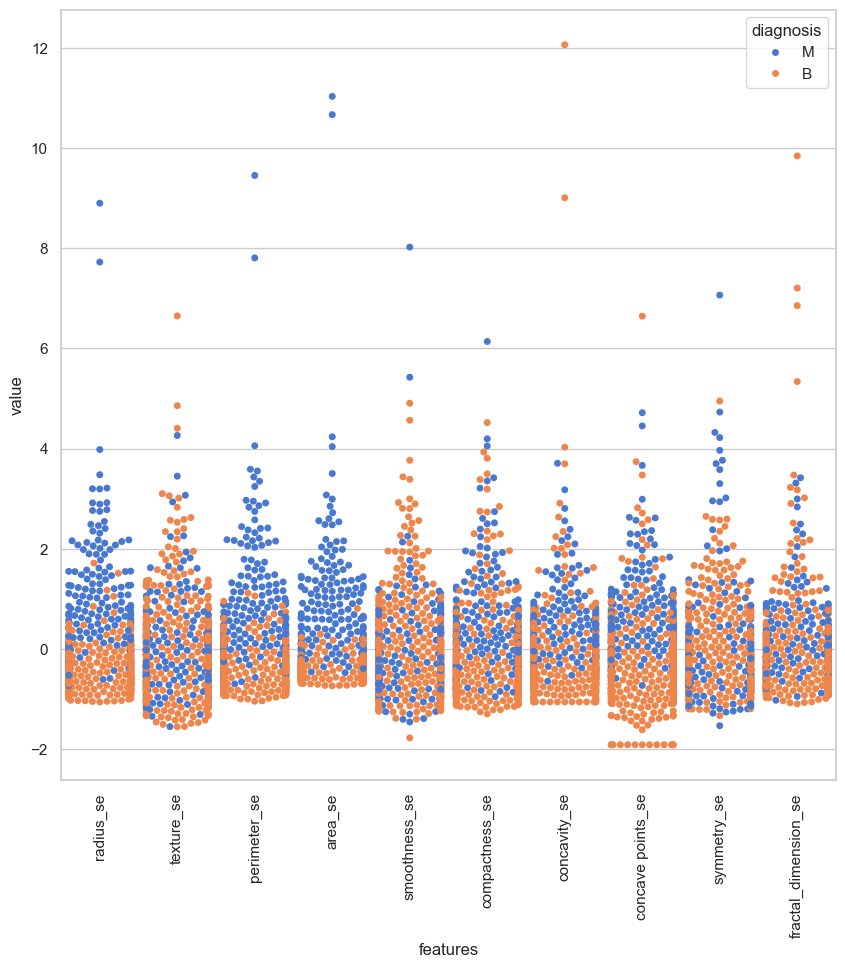

In [7]:
#Getting all features from 10th to 20th
data_vis = pd.concat([targets,data_n_2.iloc[:,10:20]],axis=1)
data_vis = pd.melt(data_vis,id_vars="diagnosis",
                    var_name="features",
                    value_name='value')
plt.figure(figsize=(10,10))
tic = time.time()
sns.swarmplot(x="features", y="value", hue="diagnosis", data=data_vis)
plt.xticks(rotation=90)
plt.show()

c:\Users\jrizz\Documentos\Programación\proyectos\AI\Supervised Machine Learning\Breast Cancer Detection\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 46.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\jrizz\Documentos\Programación\proyectos\AI\Supervised Machine Learning\Breast Cancer Detection\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 43.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\jrizz\Documentos\Programación\proyectos\AI\Supervised Machine Learning\Breast Cancer Detection\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 46.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\jrizz\Documentos\Programación\proyectos\AI\Supervised Machine Le

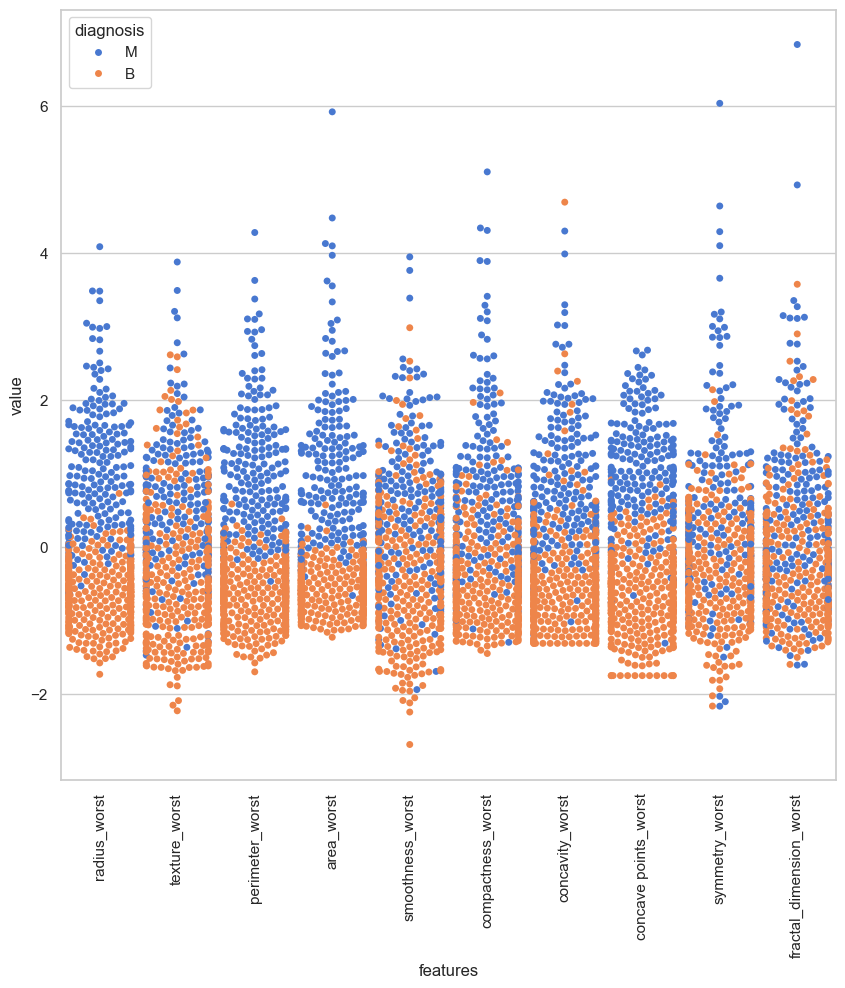

In [8]:
#Getting the last 10 features in the dataset
data_vis = pd.concat([targets,data_n_2.iloc[:,20:30]],axis=1)
data_vis = pd.melt(data_vis,id_vars="diagnosis",
                    var_name="features",
                    value_name='value')
plt.figure(figsize=(10,10))
tic = time.time()
sns.swarmplot(x="features", y="value", hue="diagnosis", data=data_vis)
plt.xticks(rotation=90)
plt.show()